Projeto Final - Módulo 1 - SCTEC
Projeto avaliativo final do curso de Desevolvimento de IA para Análise Preditiva - SCTEC: Pipeline preditivo aplicado a indústria 4.0.

# Fase 1: Análise Exploratória (EDA)

### Requisitos: 

Apresente as dimensões do dataset (número de linhas e colunas), os tipos de dados das variáveis e o resumo estatístico descritivo das colunas numéricas via método “.describe()”.

Plote, no mínimo, 3 gráficos analíticos bem fundamentados utilizando bibliotecas como Matplotlib ou Seaborn (Ex: histograma de distribuição das variáveis preditoras, gráfico de barras comprovando a taxa de desbalanceamento da variável alvo e um mapa de calor com a correlação de Pearson entre as variáveis).

Insira uma célula de texto analisando os valores numéricos e os padrões identificados nos gráficos, explicitando como eles direcionam a estratégia de modelagem.

In [35]:
## Antes de começar é necessário selecionar o Kernel ".venv" e configurar os notebooks
 
# Configuração inicial dos notebooks (ver o src.config)

# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração do visual global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("\n=== CONFIGURAÇÕES E BIBLIOTECAS IMPORTADAS COM SUCESSO ===")


=== CONFIGURAÇÕES E BIBLIOTECAS IMPORTADAS COM SUCESSO ===


In [36]:
## Carregando o dataset

# Leitura do arquivo
df = pd.read_csv("../data/raw/manutencao_preditiva.csv", sep=",")
print("\n --- ARQUIVO LIDO COM SUCESSO ---")
df.head()


 --- ARQUIVO LIDO COM SUCESSO ---


,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [37]:
## Analisando o dataset

# Apresentar as dimenções do dataset
print("\n --- DIMENSÕES DO DATA SET ---")
print(f"NÚMERO DE LINHAS: {df.shape[0]}")
print(f"NÚMERO DE COLUNAS: {df.shape[1]}")

print("\n --- TIPO DE DADOS DAS VARIÁVEIS ---")
print(df.info())

print("\n --- RESUMO ESTATÍSTICO DESCRITIVO ---")
df.describe()


 --- DIMENSÕES DO DATA SET ---
NÚMERO DE LINHAS: 10000
NÚMERO DE COLUNAS: 14

 --- TIPO DE DADOS DAS VARIÁVEIS ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  str    
 2   tipo                     10000 non-null  str    
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                1

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### Análise gráfica dos dados ainda sem tratamento

Representaçãoes gráficas podem ser utilizadas para compreender como os dados se comportam. 
E, como objetivo deste projeto é prever quebras mecânicas nos equipamentos para evitar paradas na linha de produção, os gráficos de diagnóstico inicial também podem focar no comportamento de opereração normal versus o comportamento que antecede a quebra.
Nesta análise exploratória utilizamos estas duas abordagens.

In [38]:
# Para os gráficos serem salvos na pasta "outputs"

def salvar_grafico(nome_arquivo, etapa="01_eda", output_base_dir="../outputs/graficos"): # cria a subpasta para a etapa atual e exporta o gráfico gerado
    output_dir = os.path.join(output_base_dir, etapa)
    os.makedirs(output_dir, exist_ok=True) # cria o caminho dinâmico

    caminho_completo = os.path.join(output_dir, f"{nome_arquivo}.png") # define o caminho final do arquivo de imagem

    plt.savefig(caminho_completo, dpi=300, bbox_inches="tight")
    print(f"Grafico salvo em:{caminho_completo}") #salva o grafico atual

Grafico salvo em:../outputs/graficos\01_eda\01_distribuição das variáveis.png


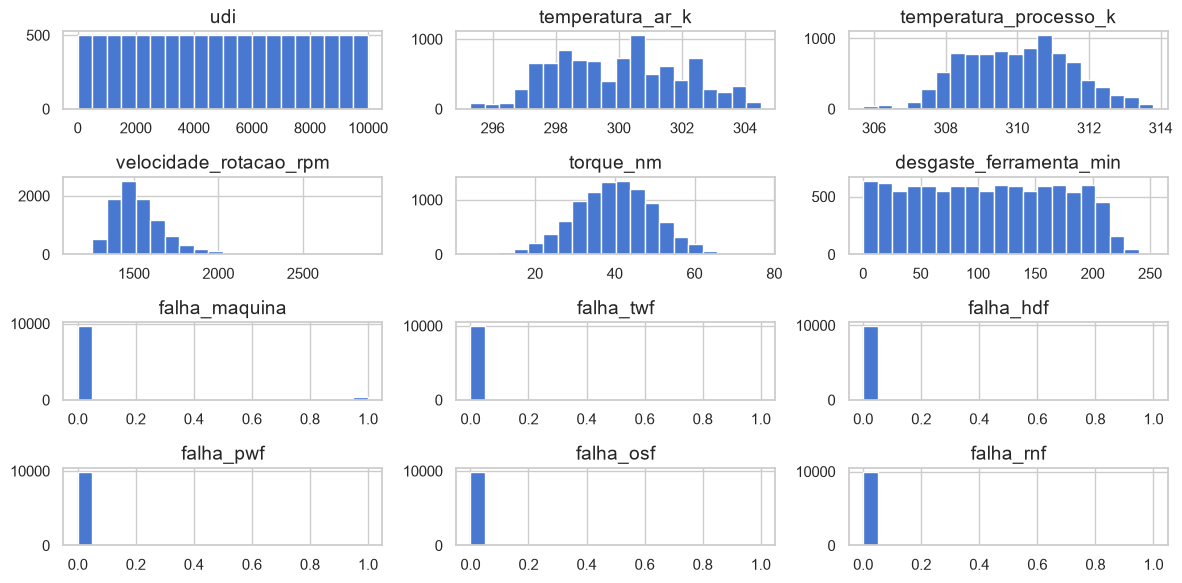

In [39]:
# Histograma para análise da distribuição das variáveis preditoras

df.hist(bins=20)

plt.tight_layout()
salvar_grafico("01_distribuição das variáveis")
plt.show()


Grafico salvo em:../outputs/graficos\01_eda\01_desbalanceamento_alvo.png


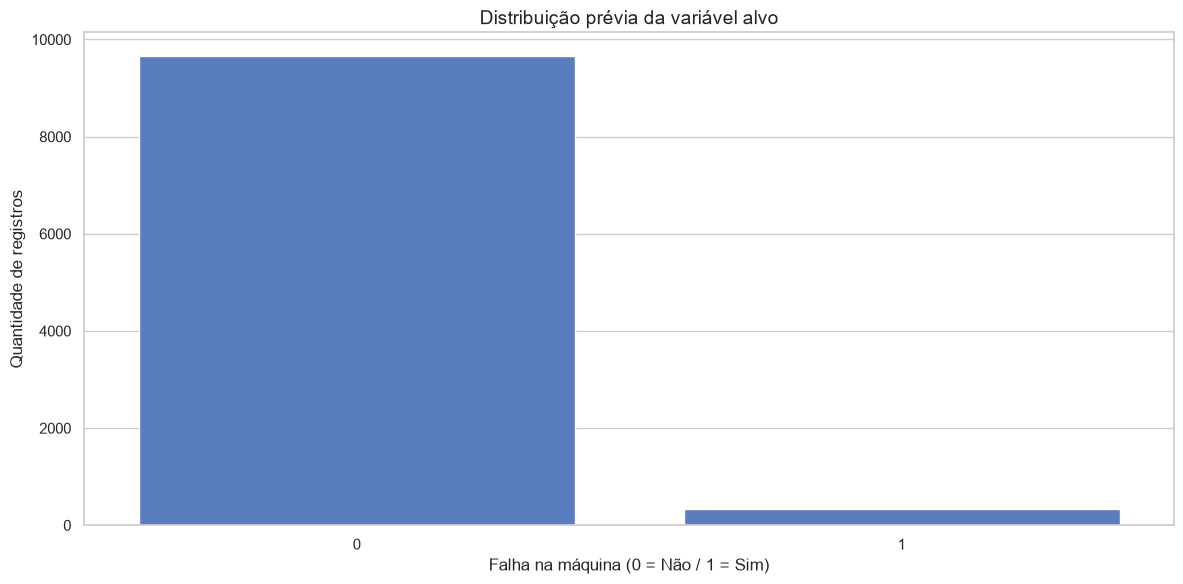

In [40]:
# Gráfico de barras para análise do desbalanceamento da variável alvo

sns.countplot(data=df,x='falha_maquina')
plt.title("Distribuição prévia da variável alvo")
plt.xlabel("Falha na máquina (0 = Não / 1 = Sim)")
plt.ylabel(("Quantidade de registros"))

plt.tight_layout()
salvar_grafico("01_desbalanceamento_alvo")
plt.show()

Grafico salvo em:../outputs/graficos\01_eda\01_mapa_de_calor.png


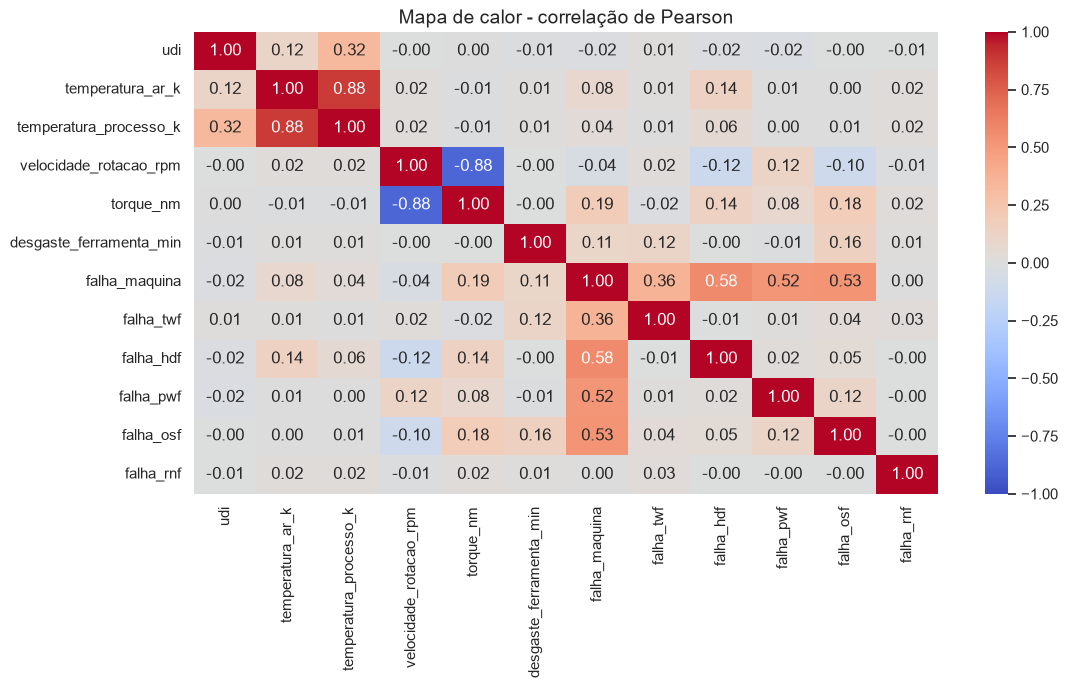

In [41]:
# Mapa de calor: diagnóstico de correlação das variáveis
# O mapa de calor é o gráfico que mostra imediatamente a correlação entre as falhas e as variáveis, além de ignorar valores ausentes e direcionar a limpeza dos outliers.

# Cálculo da matriz de correlação de Pearson
matriz_correlacao = df.corr(method='pearson', numeric_only=True)

# Gráfico
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Mapa de calor - correlação de Pearson")
salvar_grafico("01_mapa_de_calor")
plt.show()

Análise:

Observando o conjunto de histogramas de distribuição das variáveis nota-se que as variáveis preditoras contínuas (temperaturas, torque e velocidade) apresentam uma distribuição em forma de sino, bem próxima da normal, com dados bem distribuídos. Já atributos como udi e desgaste_ferramenta_min possuem uma distribuição uniforme, com comportamento de plano. E, as variáveis de tipo de falha estão concentradas em apenas uma barra, mostrando desbalanceamento. No entanto os valores numéricos dos eixos são muito distantes entre si, indicando a necessidade de futura aplicação de padronização de escalas para equilibrar o peso dessas variáveis no modelo. 
O gráfico de barras da variável alvo comprova um desbalanceamento intenso, com uma quantidade de falhas muito pequena dentro do conjunto de dados. Este comportamento evidencia que o modelo não pode ser treinado diretamente, sendo obrigatória a aplicação de técnicas de balanceamento dos dados.
Pelo mapa de calor é possível observar uma correlação muito forte, quase linear, entre as temperaturas do ar e de processo (0.88) e entre a velocidade de rotação e o torque (-0.88). O sinal negativo na correlação entre a velocidade de rotação e o torque indica que a correlação é inversa, ou seja, quando aumenta a velocidade de rotação, reduz-se o torque, um comportamento esperado na mecânica. Já para a temperatura, a correlação é positiva, indicando que quando o ar está mais aquecido, o processo também apresenta temperaturas mais elevadas.
Desconsiderando as variáveis que indicam o tipo de falha, é possível observar que o torque e o desgaste da ferramenta são as variáveis com maior correlação com a variável de falha. Apesar disso, os valores são muito baixos, indicando que não existe uma correlação linear direta e simples. A causa das quebras deve ser multifatorial. O histograma das variáveis com maiores correlações vai ajudar a entender o comportamento físico das máquinas através da distribuição dos dados com falha e em condições sem falha.


Grafico salvo em:../outputs/graficos\01_eda\01_histogramas_torque_desgaste.png


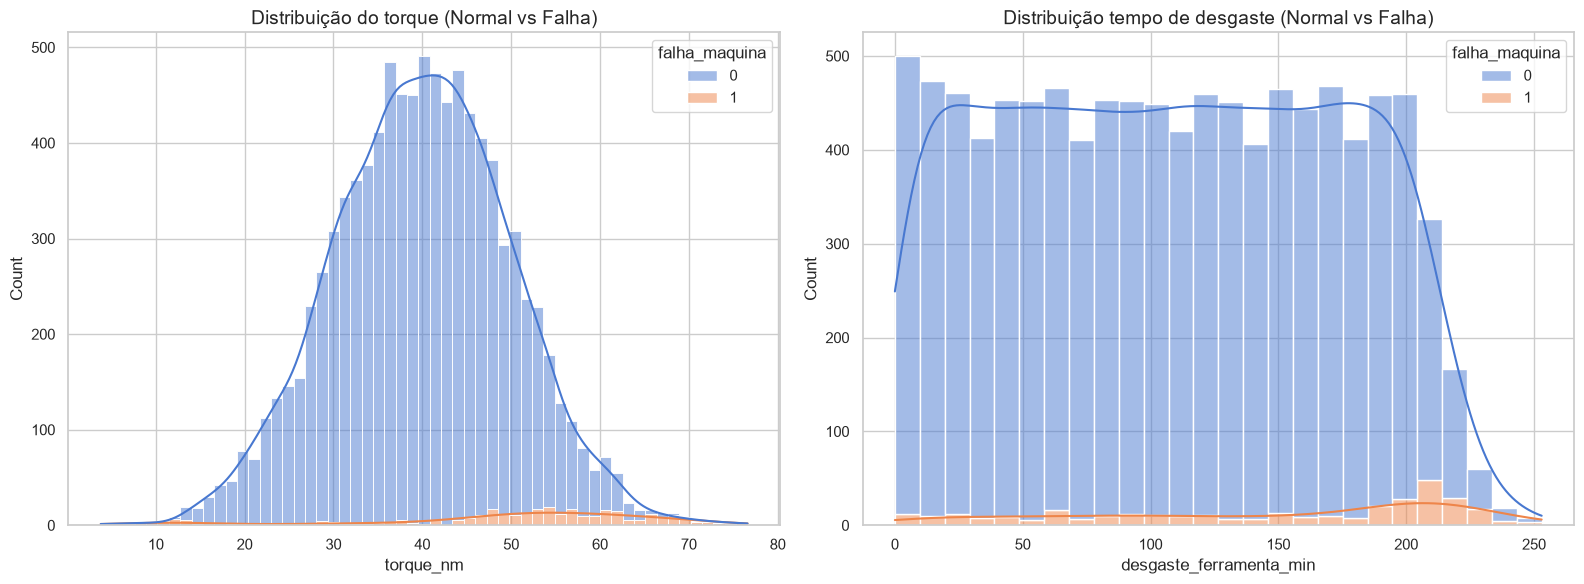

In [42]:
# Histogramas das variáveis com maiores correlações com as falhas

fig, axes = plt.subplots(1, 2, figsize=(16,6)) # para os gráficos sairem lado a lado

# Histograma do torque
sns.histplot(data=df, x='torque_nm', hue='falha_maquina', kde=True, ax=axes[0], multiple="stack") # o hue faz o histograma mostrar em cores diferentes quando há (1) e quando não há falha (0)
axes [0].set_title('Distribuição do torque (Normal vs Falha)')

# Histograma do desgaste da ferramenta
sns.histplot(data=df, x='desgaste_ferramenta_min', hue='falha_maquina', kde=True, ax=axes[1], multiple="stack") 
axes [1].set_title('Distribuição tempo de desgaste (Normal vs Falha)')

plt.tight_layout()
salvar_grafico("01_histogramas_torque_desgaste")
plt.show()


Análise:

Pelo histograma do torque é possível observar que as falhas começam a partir de 42Nm. Abaixo disso, as máquina operam em segurança e acima, os equipamentos estão mais vulneráveis a quebra por sobrecarga.
Já o histograma do desgaste da ferramenta mostra que existem falhas desde o minuto zero, mas com um pico entre 190 e 240 minutos, que indica o fim da vida útil da ferramenta por desgaste natural (fadiga).
Para comparar a média do tempo de desgaste da ferramenta para as condições de operação normal e com falha, foi gerado um gráfico de barras:

Grafico salvo em:../outputs/graficos\01_eda\01_tempo_medio_desgate.png


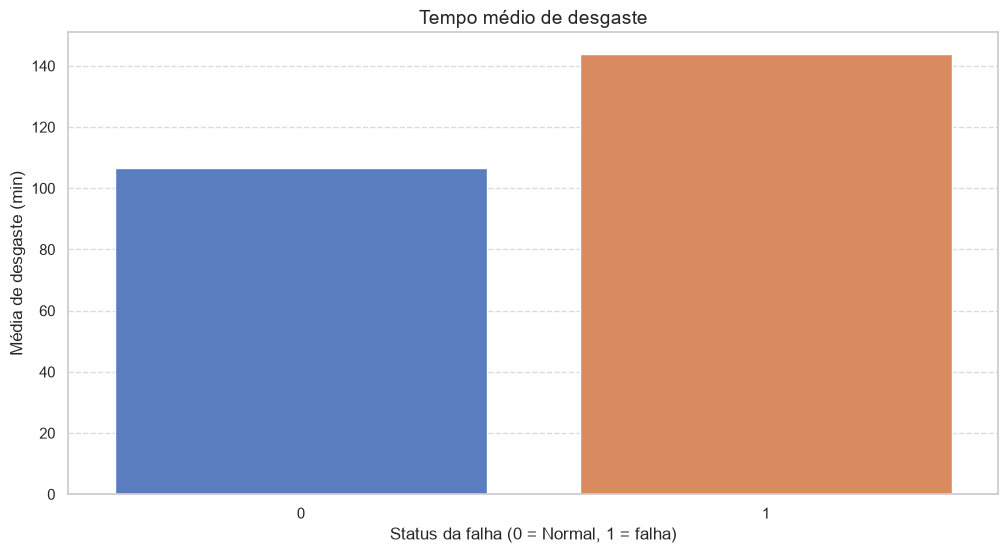

In [43]:
# Gráfico de barras para o tempo médio de operação normal e de falha

sns.barplot(data=df, x='falha_maquina', y='desgaste_ferramenta_min', palette='muted', hue='falha_maquina', legend=False, errorbar=None)

plt.title("Tempo médio de desgaste")
plt.xlabel('Status da falha (0 = Normal, 1 = falha)')
plt.ylabel('Média de desgaste (min)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
salvar_grafico("01_tempo_medio_desgate")
plt.show()

Análise: 

Este gráfico de barras mostra a média de aproximadamente 100 minutos para a operação normal e de 140 minutos para a operação com falha mostra que o desgaste acumulado aumetna a chance de falha. No entanto, se as quebras acontececem somente por desgaste avançado, a média da barra com falha deveria ser mais alta, perto de 200 minutos, que é o pico mostrado no histograma. A média do tempo de falha por desgaste está sendo afetada pelas quebras prematuras, que aparecem desde o tempo zero no histograma.

# Fase 2: Limpeza e Tratamento de Dados (Data Prep)

Requisitos: 

Identifique e remova as linhas duplicadas.

Identifique dados ausentes e aplique a imputação por Média ou Mediana, justificando textualmente a escolha com base na distribuição dos dados.

Gere gráficos do tipo boxplot para identificar a presença de outliers nas variáveis explicativas.

In [44]:
# Identificando duplicados

print("\n --- QUANTIDADE DE DUPLICADOS ---")
df.duplicated().sum()


 --- QUANTIDADE DE DUPLICADOS ---


np.int64(0)

Análise

Não há duplicados

In [45]:
# Identificando valores ausentes

print("\n --- QUANTIDADE DE DADOS AUSENTES ---")
df.isna().sum()


 --- QUANTIDADE DE DADOS AUSENTES ---


udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64

In [46]:
# Analisando as colunas com valores ausentes

colunas = ["temperatura_ar_k", "temperatura_processo_k", "velocidade_rotacao_rpm", "torque_nm"]


resumo = pd.DataFrame({
    "Valores ausentes": df[colunas].isnull().sum(),
    "Mínimo": df[colunas].min(),
    "Máximo": df[colunas].max(),
    "Média": df[colunas].mean(),
    "Mediana": df[colunas].median(),
    "Desvio padrão": df[colunas].std()
    })

resumo

,Valores ausentes,Mínimo,Máximo,Média,Mediana,Desvio padrão
temperatura_ar_k,500,295.3,304.5,300.002158,300.1,2.001689
temperatura_processo_k,500,305.7,313.8,310.000895,310.1,1.486432
velocidade_rotacao_rpm,500,1168.0,2886.0,1539.245263,1504.0,180.273589
torque_nm,500,3.8,76.6,39.974168,40.1,9.995453


Análise

Foram identificados 500 valores ausentes nas variáveis temperatura do ar, temperatura do processo, velocidade de rotação e torque. Os valores ausentes representam, portanto, cerca de 5% do total de registros em cada variável. Para evitar a redução do conjunto de dados, os dados ausentes podem ser substituídos pela média ou pela mediana. Neste projeto, optou-se pela imputação da mediana, baseada na análise estatística descritiva, que mostrou que as variáveis de temperatura apresentam média e mediana praticamente iguais, mas as variáveis de velocidade de rotação e torque apresentaram uma diferença um pouco maior entre média e mediana, sugerindo maior dispersão dos dados e possível infuência de outliers.
A mediana é menos afetada pela presença destes valores extremos, preserva melhor as características originais dos dados e reduz o risco de distorções do modelo.

In [47]:
# Tratando valores ausentes

# Fazendo uma cópia do banco de dados para tratamento
df_tratado = df.copy()
           
# Substituindo os valores ausentes destas colunas pela mediana
for coluna in colunas:
    df_tratado[coluna] = df_tratado[coluna].fillna(df_tratado[coluna].median())

# Salvando a base de dados tratada
df_tratado.to_csv("../data/processed/manutencao_preditiva_tratado.csv", index=False)

# Checando substituição dos nulos

print("\n --- DADOS AUSENTES TRATADOS COM SUCESSO ---")
df_tratado.isna().sum()


 --- DADOS AUSENTES TRATADOS COM SUCESSO ---


udi                        0
id_produto                 0
tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
falha_hdf                  0
falha_pwf                  0
falha_osf                  0
falha_rnf                  0
dtype: int64

Grafico salvo em:../outputs/graficos\02_data_prep\02_boxplot_todas.png


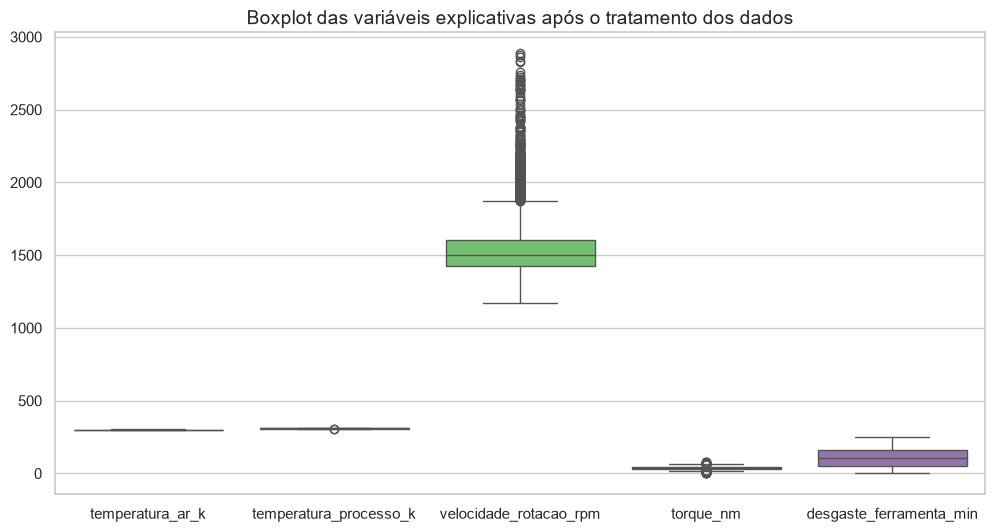

In [48]:
# Para os gráficos serem salvos na pasta "outputs"

def salvar_grafico(nome_arquivo, etapa="02_data_prep", output_base_dir="../outputs/graficos"): # cria a subpasta para a etapa atual e exporta o gráfico gerado
    output_dir = os.path.join(output_base_dir, etapa)
    os.makedirs(output_dir, exist_ok=True) # cria o caminho dinâmico

    caminho_completo = os.path.join(output_dir, f"{nome_arquivo}.png") # define o caminho final do arquivo de imagem

    plt.savefig(caminho_completo, dpi=300, bbox_inches="tight")
    print(f"Grafico salvo em:{caminho_completo}") #salva o grafico atual

# Gerando o boxplot
variaveis_explicativas = ["temperatura_ar_k", "temperatura_processo_k", "velocidade_rotacao_rpm", "torque_nm","desgaste_ferramenta_min"]
plt.figure(figsize=(12,6))
sns.boxplot(data=df_tratado[variaveis_explicativas])
plt.title ("Boxplot das variáveis explicativas após o tratamento dos dados")
plt.xticks(rotation=0)
salvar_grafico("02_boxplot_todas")
plt.show()

Análise

O gráfico ficou com algumas variáveis mal representadas devido a diferença de escala. Para melhorar a visualização foram feitos gráficos separados para cada uma delas. 

Grafico salvo em:../outputs/graficos\02_data_prep\02_boxplot_isoladas.png


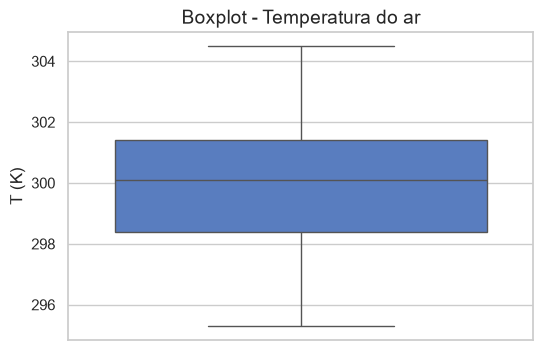

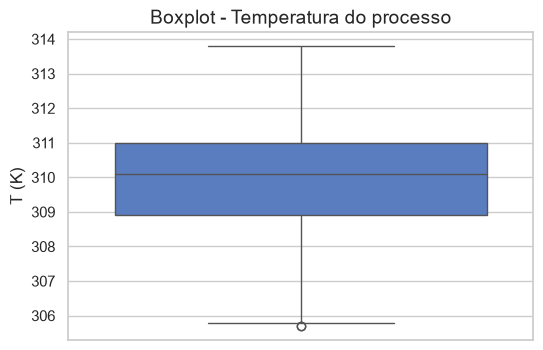

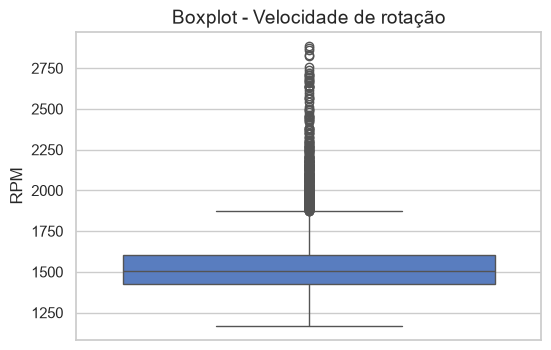

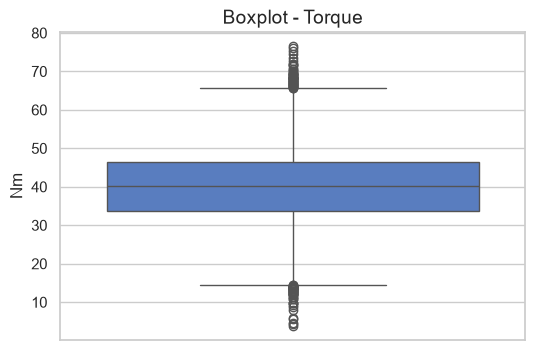

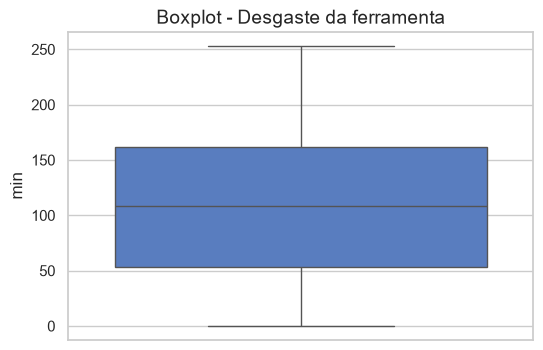

In [49]:
# Boxplot por variável explicativa

# Temperatura do ar
plt.figure(figsize=(6,4))
sns.boxplot(data=df_tratado["temperatura_ar_k"])
plt.title ("Boxplot - Temperatura do ar")
plt.ylabel("T (K)")

# Temperatura do processo
plt.figure(figsize=(6,4))
sns.boxplot(data=df_tratado["temperatura_processo_k"])
plt.title ("Boxplot - Temperatura do processo")
plt.ylabel("T (K)")

# Velocidade de rotação
plt.figure(figsize=(6,4))
sns.boxplot(data=df_tratado["velocidade_rotacao_rpm"])
plt.title ("Boxplot - Velocidade de rotação")
plt.ylabel("RPM")

# Torque
plt.figure(figsize=(6,4))
sns.boxplot(data=df_tratado["torque_nm"])
plt.title ("Boxplot - Torque")
plt.ylabel("Nm")

# Desgaste da ferramenta
plt.figure(figsize=(6,4))
sns.boxplot(data=df_tratado["desgaste_ferramenta_min"])
plt.title ("Boxplot - Desgaste da ferramenta")
plt.ylabel("min")


salvar_grafico("02_boxplot_isoladas")
plt.show()

Análise

Os outliers são representados pelos círculos localizados além dos limites. A variável velocidade de rotação e o torque apresentaram a maior concentração de outliers. Os outliers foram mantidos para as próximas análises.

# Fase 3: Feature Engineering

Requisitos:

Crie uma nova coluna numérica por meio de operação matemática entre colunas existentes, tratando os valores nulos previamente.

Sugestão (Manutenção): potencia = velocidade_rotacao_rpm * torque_nm

(É permitida a criação de outra combinação matemática, desde que explicada no vídeo e documentada no notebook).

In [50]:
# Removendo as colunas que não serão usados

df_fe = df_tratado.drop(
    columns=[
        "udi",
        "falha_twf",
        "falha_hdf",
        "falha_pwf",
        "falha_osf",
        "falha_rnf"
    ]
)
print("\n --- COLUNAS DESNECESSÁRIAS REMOVIDAS COM SUCESSO ---")
df_fe.head()


 --- COLUNAS DESNECESSÁRIAS REMOVIDAS COM SUCESSO ---


,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina
0,M14860,M,298.1,308.6,1551.0,42.8,0,0
1,L47181,L,298.2,308.7,1408.0,46.3,3,0
2,L47182,L,298.1,308.5,1498.0,49.4,5,0
3,L47183,L,300.1,310.1,1504.0,40.1,7,0
4,L47184,L,298.2,308.7,1408.0,40.0,9,0


In [51]:
# Criando uma nova coluna 

# potencia = velocidade_rotacao_rpm * torque_nm, conforme sugerido, sem a preocupação com a unidade física exata da potência.

df_fe["potencia_calc"] = (df_fe["velocidade_rotacao_rpm"] * df_fe["torque_nm"])
print("\n --- COLUNA DE POTÊNCIA CRIADA COM SUCESSO ---")
df_fe.head()


 --- COLUNA DE POTÊNCIA CRIADA COM SUCESSO ---


,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,potencia_calc
0,M14860,M,298.1,308.6,1551.0,42.8,0,0,66382.8
1,L47181,L,298.2,308.7,1408.0,46.3,3,0,65190.4
2,L47182,L,298.1,308.5,1498.0,49.4,5,0,74001.2
3,L47183,L,300.1,310.1,1504.0,40.1,7,0,60310.4
4,L47184,L,298.2,308.7,1408.0,40.0,9,0,56320.0


In [52]:
# Analisando os dados desta nova coluna

print("\n --- RESUMO ESTATÍSTICO DESCRITIVO DA POTÊNCIA ---")
df_fe["potencia_calc"].describe()


 --- RESUMO ESTATÍSTICO DESCRITIVO DA POTÊNCIA ---


count    10000.000000
mean     59970.673120
std       9951.344325
min      10966.800000
25%      53497.050000
50%      60310.400000
75%      66412.975000
max      99980.400000
Name: potencia_calc, dtype: float64

In [53]:
# Salvando a base de dados de engenharia
df_fe.to_csv("../data/processed/manutencao_preditiva_fe.csv", index=False)

Grafico salvo em:../outputs/graficos\03_fe\03_histograma_potencia.png


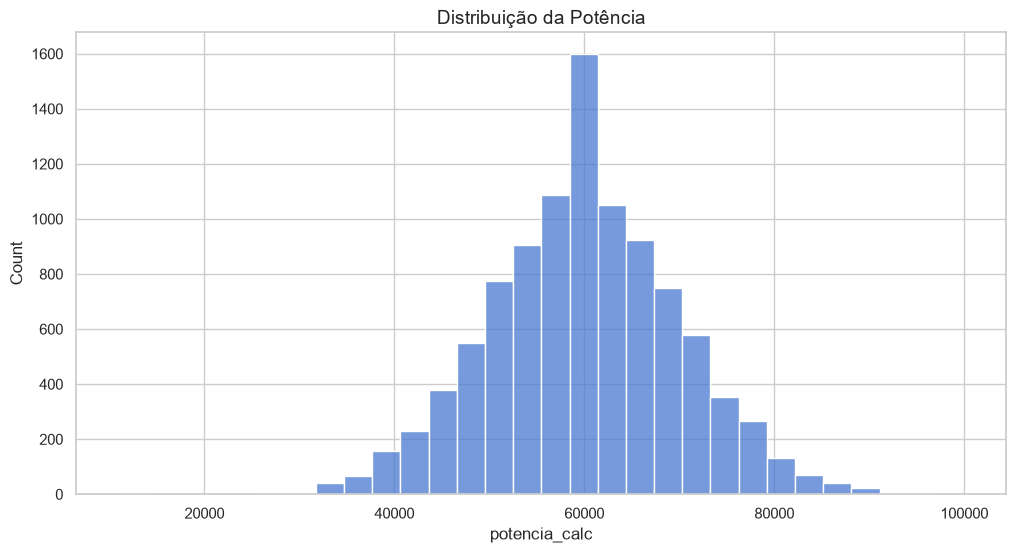

In [54]:
# Histograma da potência

# Para os gráficos serem salvos na pasta "outputs"

def salvar_grafico(nome_arquivo, etapa="03_fe", output_base_dir="../outputs/graficos"): # cria a subpasta para a etapa atual e exporta o gráfico gerado
    output_dir = os.path.join(output_base_dir, etapa)
    os.makedirs(output_dir, exist_ok=True) # cria o caminho dinâmico

    caminho_completo = os.path.join(output_dir, f"{nome_arquivo}.png") # define o caminho final do arquivo de imagem

    plt.savefig(caminho_completo, dpi=300, bbox_inches="tight")
    print(f"Grafico salvo em:{caminho_completo}") #salva o gráfico atual

sns.histplot(df_fe["potencia_calc"], bins=30)
plt.title("Distribuição da Potência")
salvar_grafico("03_histograma_potencia")
plt.show()

Grafico salvo em:../outputs/graficos\03_fe\03_boxplot_potencia.png


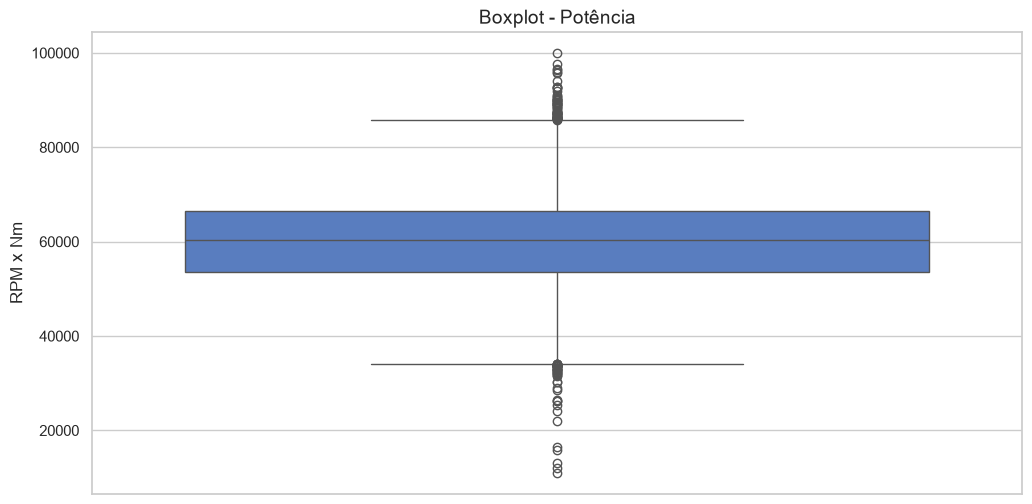

In [55]:
# Boxplot da potência

sns.boxplot(data=df_fe["potencia_calc"])
plt.title ("Boxplot - Potência")
plt.ylabel("RPM x Nm")
salvar_grafico("03_boxplot_potencia")
plt.show()

Análise

Analisando os gráficos da potência calculada, pelo histograma observa-se que os dados possuem uma distribuição bastante simétrica e com formato de uma curva normal. Esta distribuição sugere que a variável criada preservou um comportamento consistente e pode fornecer informações relevantes para a etapa de modelagem preditiva. A maior concentração dos valores está em torno de 60.000 RPM x Nm, indicando que a maior parte das máquinas opera dentro desta faixa. Já no boxplot, observa-se uma distribuição relativamente equilibrada dos dados, concentrados em torno da mediana. Também são observados outliers, tanto acima quanto abaixo dos limites. Os outliers foram mantidos para o aprendizado do modelo.

# Fase 4: Divisão e Balanceamento dos Dados

Requisitos:

Separe as variáveis preditoras (X) da variável alvo (y).

Divida os dados em treino (80%) e teste (20%) utilizando o parâmetro stratify=y.

Aplique uma técnica de reamostragem (SMOTE ou Random Under Sampling) exclusivamente nos dados de treino para evitar o vazamento de dados (Data Leakage).


In [56]:
# Separando as variáveis preditoras (x) eliminando a coluna da variável alvo (falha_maquina)

X = df_fe.drop(columns=["falha_maquina"]) # X é maiúsculo
print("\n --- SEPARAÇÃO DAS VARIÁVEIS PREDITORAS REALIZADO COM SUCESSO ---")
X.head()


 --- SEPARAÇÃO DAS VARIÁVEIS PREDITORAS REALIZADO COM SUCESSO ---


,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,potencia_calc
0,M14860,M,298.1,308.6,1551.0,42.8,0,66382.8
1,L47181,L,298.2,308.7,1408.0,46.3,3,65190.4
2,L47182,L,298.1,308.5,1498.0,49.4,5,74001.2
3,L47183,L,300.1,310.1,1504.0,40.1,7,60310.4
4,L47184,L,298.2,308.7,1408.0,40.0,9,56320.0


In [57]:
# Isolando apenas a variável alvo

y = df_fe["falha_maquina"] # y é minúsculo
print("\n --- ISOLAMENTO DA VARIÁVEL ALVO REALIZADO COM SUCESSO ---")
y.head()



 --- ISOLAMENTO DA VARIÁVEL ALVO REALIZADO COM SUCESSO ---


0    0
1    0
2    0
3    0
4    0
Name: falha_maquina, dtype: int64

In [58]:
# Dividindo a base de dados em treino (80%) e teste (20%)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("\n --- DIVISÃO DOS DADOS REALIZADA COM SUCESSO ---")
print(f"Dimensões de treino (X_train): {X_train.shape}") # (quantidade de linhas, colunas)
print(f"Dimensões de teste (X_test): {X_test.shape}")



 --- DIVISÃO DOS DADOS REALIZADA COM SUCESSO ---
Dimensões de treino (X_train): (8000, 8)
Dimensões de teste (X_test): (2000, 8)


In [59]:
# Balanceamento de classes por reamostragem (Random Under Sampling)
# serve para evitar que o modelo "chute" a resposta mais frequente

# importando a ferramente resample
from sklearn.utils import resample

treino_completo = pd.concat([X_train, y_train], axis=1)
classe_normal = treino_completo[treino_completo['falha_maquina'] == 0]
classe_falha = treino_completo[treino_completo['falha_maquina'] == 1]

# Reduzindo a classe majoritária para o tamanho da minoritária
classe_normal_subamostrada = resample(
    classe_normal, replace=False, n_samples=len(classe_falha), random_state=42
) 

treino_balanceado = pd.concat([classe_normal_subamostrada, classe_falha])
X_train_bal = treino_balanceado.drop(columns=['falha_maquina'])
y_train_bal = treino_balanceado['falha_maquina']

print("\n --- BALANCEAMENTO REALIZADO COM SUCESSO ---")
y_train_bal.value_counts() # mostra a quantidade de linhas de cada uma (0 e 1). Devem ser iguais.


 --- BALANCEAMENTO REALIZADO COM SUCESSO ---


falha_maquina
0    271
1    271
Name: count, dtype: int64

# Fase 5: Escalonamento de Variáveis (StandardScaler)

Requisitos:

Aplique o StandardScaler apenas nas variáveis contínuas destinadas ao modelo KNN (utilizando fit_transform no treino e transform no teste).

Mantenha os dados da Árvore de Decisão sem escalonamento, justificando no código o motivo de o algoritmo ser imune à escala dos atributos.


In [60]:
# Listando (isolando) as variáveis contínuas que possuem escalas muito distantes
colunas_continuas=["velocidade_rotacao_rpm", "torque_nm", "potencia_calc", "temperatura_ar_k", "temperatura_processo_k"]


# Importando a ferramenta StandardScaler
from sklearn.preprocessing import StandardScaler

# Aplicando o StandardScaler de forma segura para o KNN
# Serve para colocar todas as colunas numéricas na mesma escala, com média 0 e desvio padrão 1, para que a comparação seja justa
scaler = StandardScaler()
X_train_knn = X_train_bal.copy()
X_test_knn = X_test.copy()

X_train_knn[colunas_continuas] = scaler.fit_transform(X_train_knn[colunas_continuas])
X_test_knn[colunas_continuas] = scaler.transform(X_test_knn[colunas_continuas])

print("\n --- ESCALONAMENTO REALIZADO COM SUCESSO ---")
X_train_knn.head()


 --- ESCALONAMENTO REALIZADO COM SUCESSO ---


,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,potencia_calc
4497,L51677,L,1.008574,0.118924,0.048896,-0.664263,72,-0.694809
949,L48129,L,-2.391033,-2.717462,0.446172,-0.903587,56,-0.786590
6377,L53557,L,-0.173898,-0.377443,0.112179,-0.591740,96,-0.543839
649,M15509,M,-1.356370,-0.661082,0.783681,-1.186424,152,-1.035948
5179,M20039,M,1.747618,2.104394,-0.207752,-0.171110,101,-0.196038


### Justificativa para a Árvore de Decisão não precisar de escalonamento

As variáveis para a Árvore de decisão são as geradas na etapa anterior: X_train_bal e X_test.
Elas não precisam de tratamento  StandardScaler, pois a Árvore de decisão é um algoritmo que toma decisões criando um fluxograma de perguntas de maior ou menor (regras de corte), analisando coluna a coluna, de forma isolada e, portanto, permanecendo imune a escala, magnitude ou tamanho dos números das outras colunas.

Já o KNN usa geometria e requer escalonamento dos dados para que os números grandes não esmaguem os números pequenos. 


# Fase 6: Ajuste de Parâmetros e Combate ao Overfitting 

Requisitos:

No KNN: Treine o modelo variando o parâmetro n_neighbors (K) por no mínimo 3 valores ímpares (ex: K = 3, 5, 7) e registre a acurácia no treino e no teste. 

Na Árvore: Treine o modelo variando o parâmetro max_depth por no mínimo 3 limites (ex: 3, 5 e None) e registre a acurácia no treino e no teste. 

Insira um texto identificando em quais pontos ocorreu o overfitting e qual configuração garantiu a estabilidade no teste. 


In [61]:
# Importação as ferramentas

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [62]:
# Ajuste do treino do KNN

valores_k = [3, 5, 7]
knn_resultados = {}

print("\n --- RESULTADOS DO AJUSTE DO KNN ---")
for k in valores_k:
    knn_ajustado = KNeighborsClassifier(n_neighbors=k) # para instanciar o modelo com o k da vez
    knn_ajustado.fit(X_train_knn[colunas_continuas], y_train_bal) # para treinar o modelo
    # Previsões para a base teste e treino(para ver o Overfitting)
    knn_preds_teste = knn_ajustado.predict(X_test_knn[colunas_continuas])
    knn_preds_treino = knn_ajustado.predict(X_train_knn[colunas_continuas])

    # Avaliar a precisão dos dados de teste
    acc_teste = accuracy_score(y_test, knn_preds_teste)
    acc_treino = accuracy_score(y_train_bal, knn_preds_treino)
    knn_resultados[k] = {'treino': acc_treino, 'teste': acc_teste}
    print(f"K = {k} | Treino: {acc_treino:.2f} | Teste: {acc_teste:.2f}")



 --- RESULTADOS DO AJUSTE DO KNN ---
K = 3 | Treino: 0.87 | Teste: 0.84
K = 5 | Treino: 0.85 | Teste: 0.87
K = 7 | Treino: 0.84 | Teste: 0.88


In [63]:
# Ajuste do treino da Árvore de decisão

valores_depth = [3, 5, None]
tree_resultados = {}

print("\n --- RESULTADOS DO AJUSTE DA ÁRVORE DE DECISÃO ---")
for depth in valores_depth:
    tree_ajustada = DecisionTreeClassifier(max_depth=depth, random_state=42) # para instanciar o modelo
    tree_ajustada.fit(X_train_bal[colunas_continuas], y_train_bal) # para treinar o modelo
    # Previsões para a base teste e treino(para ver o Overfitting)
    tree_preds_teste = tree_ajustada.predict(X_test[colunas_continuas])
    tree_preds_treino = tree_ajustada.predict(X_train_bal[colunas_continuas])

    # Avaliar a precisão dos dados de teste
    acc_teste = accuracy_score(y_test, tree_preds_teste)
    acc_treino = accuracy_score(y_train_bal, tree_preds_treino)
    chave = 'None' if depth is None else depth
    tree_resultados[chave] = {'treino': acc_treino, 'teste': acc_teste}
    print(f"Max Depht = {chave} | Treino: {acc_treino:.2f} | Teste: {acc_teste:.2f}")



 --- RESULTADOS DO AJUSTE DA ÁRVORE DE DECISÃO ---
Max Depht = 3 | Treino: 0.84 | Teste: 0.89
Max Depht = 5 | Treino: 0.87 | Teste: 0.89
Max Depht = None | Treino: 0.98 | Teste: 0.74


Análise:

Observando os resultados da acuracia de treino e teste, foi observado overfitting no modelo de Árvore de Decisão para o Max Depth = None, uma vez que em treino, a acuracia foi de 0.98, muito próxima a 1.00, mas, no teste, houve uma queda para 0.74, indicando perda de precisão com novos dados. As demais configurações Max Depth 3 e 5, evitaram o overfitting e garantiram a estabilidade, mantendo a acurácia de teste em 0.89.

No modelo KNN não foi observado overfitting crítico. As acurácias de treino e teste se mantiveram próximas em todas as configurações. Com K = 7 obteve-se a maior estabilidade e melhor resultado, com 
acurácia de treino 0.84 e de teste 0.88.



# Fase 7: Avaliação da Acurácia e Veredito Final 

Requisitos:

Calcule e exiba a acurácia final do melhor KNN e da melhor árvore de decisão utilizando os dados de teste. 

Compare as taxas de acerto e escreva uma conclusão justificando qual modelo apresentou o desempenho superior no teste e deve ser adotado pela empresa.

In [64]:
# Melhor KNN (k=7)
melhor_knn = KNeighborsClassifier(n_neighbors=7)
melhor_knn.fit(X_train_knn[colunas_continuas], y_train_bal)

# Melhor Árvore (Max Depth=3)
melhor_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
melhor_tree.fit(X_train_bal[colunas_continuas], y_train_bal)

# Acurácias finais usando apenas os dados dos testes
pred_knn_final = melhor_knn.predict(X_test_knn[colunas_continuas])
pred_tree_final = melhor_tree.predict(X_test[colunas_continuas])

acc_knn_final = accuracy_score(y_test, pred_knn_final)
acc_tree_final = accuracy_score(y_test, pred_tree_final)

print(f"ACURÁCIA FINAL DO MELHOR KNN (K=7): {acc_knn_final:.2f}")
print(f"ACURÁCIA FINAL DA MELHOR ÁRVORE DE DECISÃO (Max Depth=3): {acc_tree_final:.2f}")


ACURÁCIA FINAL DO MELHOR KNN (K=7): 0.88
ACURÁCIA FINAL DA MELHOR ÁRVORE DE DECISÃO (Max Depth=3): 0.89


Análise:

Analisando a acurácia com os dados de teste, o modelo de Árvore de Decisão com Max Depth = 3 apresentou desempenho superior ao modelo KNN, com taxa de acerto de 0.89 contra 0.88, respectivamente.

Conclusão: 

O modelo recomendado para a empresa predizer falhas em seu equipamento de produção é o de Árvore de Decisão, justificado pela maior precisão, garantindo previsões mais confiáveis, e maior simplicidade, dispensando padronização de escalas das variáveis e com apresentação visualização facilitada para a tomada de decisão da equipe. 



In [66]:
print("\n --- CÓDIGO FINALIZADO COM SUCESSO! ---")


 --- CÓDIGO FINALIZADO COM SUCESSO! ---
